# Feature Engineering: Encoding Substructures
Scenario: You are investigating toxicity and its dependency on molecular structure. Using the LD50 Toxicity dataset by Zhu (as provided here: https://huggingface.co/datasets/scikit-fingerprints/TDC_ld50_zhu/viewer), you calculate various molecular descriptors based on the SMILES and train a Random Forest Regressor to predict toxicity. You want to see if there is an improvement of the model when you take into account chemical structure - and generally, whether chemical structure is generally related to toxicity.

Note: the dataset is based on sparse chemical space and will not deliver super high prediction scores.

#### Tasks:
1) Load and inspect the dataset `tdc_ld50_zhu.csv`.
2) Feature engineering: Create a feature matrix `X_md` by calculating descriptors (full list as in rdkit) (Snippet provided)

3) Finding common substructures (functional groups, common scaffolds) is an alternative to detecting similarities based on fingerprints. Use the provided snippets to create different structure-based features and use one-hot encoding to make them more accessible also for other models.

4) Compare the prediction performance of the model for each of the feature matrices and combinations thereof:
- X_md: molecular descriptors only
- X_scaf: One-Hot-encoded Murcko scaffolds
- X_fg: One-hot-encoded functional groups
- X_md_scaf: Concatenation of X_md and X_scaf
- X_md_scaf_fg: Concatenation of X_md, X_scaf and X_fg

Note: For every different dataset you have to perform a train-test split and train the model before predicting. You do not need to use the suggested names!

5) Pick the best one and remove low-variance features (threshold 1%), as well as highly correlated ones (threshold 90%). See if the performance of the predictions by the model improves. Hint: Use `VarianceThreshold` (Unsupervised Algorithm from Scikit-learn) and `corr_matrix = X.corr().abs()` to do so (e.g. similarly as used in the Clustering example on the ESOL dataset)

6) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.

7) Use Butina clustering on UMAP visualisation of the smiles-fingerprint space (scatterplot) and compare the plot side by side (e.g. as suplots) with a scatterplot colourmapped to the toxicity (look at options such as `colorbar` for matplotlib for better visualisation). 

8) Repeat 6 and 7 for the fingerprints based on the Murcko Scaffolds from task 3

9) Respond to the discussion points


Import dependencies and datasets

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import MolFromSmarts
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

from sklearn.manifold import TSNE
import umap

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit.ML.Cluster import Butina

1) Load and investigate the data

In [2]:
tox = pd.read_csv("tdc_ld50_zhu.csv")
tox.head()

,smiles,ld_50
0,[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,BrC(Br)Br,2.343
2,C=CBr,2.330
3,Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,S=C=Nc1ccc(Br)cc1,2.729


In [3]:
tox.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7376 entries, 0 to 7375
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   smiles  7376 non-null   object 
 1   ld_50   7376 non-null   float64
dtypes: float64(1), object(1)
memory usage: 115.4+ KB


In [4]:
tox.describe()

,ld_50
count,7376.000000
mean,2.544235
std,0.959086
min,-0.343000
25%,1.855750
50%,2.367000
75%,3.035000
max,10.207000


2) Calculate descriptors

In [5]:
descriptor_names = [d[0] for d in Descriptors._descList]

def calc_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return [desc[1](mol) for desc in Descriptors._descList]

X_md = tox.smiles.apply(calc_descriptors)

X_md = pd.DataFrame(X_md.tolist(), columns=descriptor_names)
X_md = X_md.dropna()

y = tox["ld_50"]

3) Find common scaffolds and encode them as binary vecotrs (one-hot-encoding). Note that the Scaffolds are represented as SMILES and can be used for fingerprints later

In [6]:
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

tox["scaffold"] = tox["smiles"].apply(get_scaffold).astype(str)
print(tox["scaffold"][0:5])

0    c1ccc(N=[NH+]c2ccccc2)cc1
1                             
2                             
3          c1ccc(-c2ccccc2)cc1
4                     c1ccccc1
Name: scaffold, dtype: object


OneHotEncoder for the Murcko scaffolds:

In [7]:
encoder = OneHotEncoder(sparse_output=False)

X_scaf = encoder.fit_transform(tox[["scaffold"]])

X_scaf = pd.DataFrame(
    X_scaf,
    columns=encoder.get_feature_names_out(["scaffold"]),
    index=tox.index
)

X_scaf.head()

,scaffold_,scaffold_C(#Cc1ccccc1)Cc1ccccc1,scaffold_C(=C(c1ccccc1)c1ccccc1)c1ccccc1,scaffold_C(=C1SCC(c2ccccc2)S1)n1ccnc1,scaffold_C(=CSSCC1CCCO1)NCc1cncnc1,scaffold_C(=Cc1ccccc1)C(C=Cc1ccccc1)=NN=C1NCCCN1,scaffold_C(=Cc1ccccc1)CN1CCN(c2cccnn2)CC1,scaffold_C(=Cc1ccccc1)c1ccccc1,scaffold_C(=Cc1ccco1)c1ccccn1,scaffold_C(=Cc1ccco1)c1ccco1,...,scaffold_c1ncn(C2CCCO2)n1,scaffold_c1ncnc(N(CCCCCCN(c2ncncn2)C2CCNCC2)C2CCNCC2)n1,scaffold_c1ncnc(NC2CC2)n1,scaffold_c1ncncn1,scaffold_c1ncsn1,scaffold_c1nnc(NCNc2nncs2)s1,scaffold_c1nnc[nH]1,scaffold_c1nnco1,scaffold_c1nncs1,scaffold_n1o[nH+]c2c1c1[nH+]onc1c1[nH+]onc21
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Instead of structural scaffolds (via SMARTS), encode functional groups using the one-hot-encoder. Add some more functional groups that you think have impact on the toxicity of compounds.

In [8]:
functional_groups = {
    "amine": "[NX3;H2,H1;!$(NC=O)]",
    "carboxylic_acid": "C(=O)[OX2H1]",
    "aromatic_ring": "a",
    "amide": "C(=O)N",
    "alcohol": "[OX2H][CX4]",
    "phenol": "c[OX2H]",
    "ether": "[OD2]([#6])[#6]",
    "ester": "C(=O)O[#6]",
    "ketone": "[#6][CX3](=O)[#6]",
    "aldehyde": "[CX3H1](=O)[#6]",
    "halogen": "[F,Cl,Br,I]",
    "nitro": "[NX3](=O)=O",
    "nitrile": "C#N",
    "thiol": "[SX2H]",
    "sulfide": "[SX2]([#6])[#6]",
    "sulfonamide": "S(=O)(=O)N",
    "phosphate": "P(=O)(O)(O)",
    "alkene": "C=C",
    "alkyne": "C#C"
}

In [9]:
patterns = {k: Chem.MolFromSmarts(v) for k,v in functional_groups.items()}

def detect_groups(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return {
        name: int(mol.HasSubstructMatch(pat))
        for name, pat in patterns.items()
    }

X_fg = pd.DataFrame(
    tox["smiles"].apply(detect_groups).tolist()
)

In [10]:
X_md_scaf = pd.concat([X_md, X_scaf], axis=1)

X_md_scaf_fg = pd.concat([X_md, X_scaf, X_fg], axis=1)

In [11]:
def regression_model(X,y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(random_state=42,
                                  n_estimators=50,)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    print("R2:", r2)

In [12]:
Xs = [X_md,X_scaf,X_fg,X_md_scaf,X_md_scaf_fg]

y = tox["ld_50"]

for i in Xs:
    regression_model(i,y)

R2: 0.6202269851477062
R2: 0.2088362236552953
R2: 0.2725674802762954
R2: 0.6083107708154624
R2: 0.6092215105324295


5) Pick the best one and prune the features regarding variance and correlation. Run the regression model again and compare the performance.

In [13]:
X_best = X_md

In [14]:
from sklearn.feature_selection import VarianceThreshold


var_filter = VarianceThreshold(threshold=0.01)
X_var = var_filter.fit_transform(X_best)

X_var = pd.DataFrame(
    X_var,
    columns=X_best.columns[var_filter.get_support()],
    index=X_best.index
)

In [15]:
corr = X_var.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]

X_pruned = X_var.drop(columns=to_drop)

In [16]:
regression_model(X_pruned, y)

R2: 0.6185304454967172


6) Generate Morgan fingerprints (2048 bit, radius=2) for both "smiles" (entire molecules) and "scaffolds" (SMILES of common scaffolds only)

In [17]:
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

mols = tox["smiles"].apply(Chem.MolFromSmiles)

fps_smiles = mols.apply(fpgen.GetFingerprint)

scaf_mols = tox["scaffold"].apply(Chem.MolFromSmiles)

fps_scaf = scaf_mols.apply(fpgen.GetFingerprint)

7) Butina clustering (as in last exercise): Experiment with different cutoffs and filter limits for the clusters (compare in the visualisation, no need to rerun the UMAP visualisation in between)

In [18]:
def cluster_fps(fps):
    dists = []
    nfps = len(fps)
    cutoff = 0.6

    for i in range(1, nfps):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[:i])
        dists.extend([1-x for x in sims])

    clusters = Butina.ClusterData(
        dists,
        nfps,
        cutoff,
        isDistData=True
    )
 
    print("Number of clusters:", len(clusters))
    return clusters

In [22]:
fps = list(fps_smiles)
smiles_clusters = cluster_fps(fps)
print(type(smiles_clusters))
nfps_smiles = len(fps)

fps = list(fps_scaf)
scaf_clusters = cluster_fps(fps)
print(type(scaf_clusters))
nfps_scaf = len(fps)

Number of clusters: 2408
<class 'tuple'>
Number of clusters: 747
<class 'tuple'>


In [20]:
type(smiles_clusters)

tuple

In [21]:
def print_cluster_stats(clusters, nfps):
    # filter out small clusters, rare chemoptypes, ...
    clusters_filtered = [c for c in clusters if len(c) >= 5]

    butina_labels = np.full(nfps, -1)
    for cluster_id, cluster in enumerate(clusters_filtered):
        for id in cluster:
            butina_labels[id] = cluster_id

    sizes = [len(c) for c in clusters_filtered]

    print("clusters:", len(sizes))
    print("mean size:", np.mean(sizes))
    print("max size:", np.max(sizes))
    print("singletons:", sum(s == 1 for s in sizes))

In [23]:
print_cluster_stats(smiles_clusters, nfps_smiles)
print_cluster_stats(scaf_clusters, nfps_scaf)

clusters: 334
mean size: 12.769461077844312
max size: 112
singletons: 0
clusters: 161
mean size: 40.27329192546584
max size: 1936
singletons: 0


Calculate UMAP space - play with `n_neighbors` and `min_distance` until you are satisfied with the visualisation.

In [27]:
def umap_thing(nfps, neighbours, dist):
    # convert fingerprints to numpy
    fp_array = np.zeros((nfps, 2048), dtype=int)
    for i, fp in enumerate(fps):
        DataStructs.ConvertToNumpyArray(fp, fp_array[i])
    reducer = umap.UMAP(
        n_neighbors=neighbours,
        min_dist=dist,
        random_state=42
    )

    umap_emb = reducer.fit_transform(fp_array)
    return umap_emb

In [32]:
def get_butina_labels(clusters, nfps):
    clusters_filtered = [c for c in clusters if len(c) >= 5]

    butina_labels = np.full(nfps, -1)
    for cluster_id, cluster in enumerate(clusters_filtered):
        for idx in cluster:
            butina_labels[idx] = cluster_id

    return butina_labels

In [33]:
smiles_labels = get_butina_labels(smiles_clusters, nfps_smiles)
scaf_labels = get_butina_labels(scaf_clusters, nfps_scaf)

In [51]:
smiles_embed = umap_thing(nfps_smiles, 15, 0.1)
scaf_embed = umap_thing(nfps_scaf, 20, 0.1)



c:\Users\julia\anaconda3\envs\DSA104\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\julia\anaconda3\envs\DSA104\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Visualise the UMAP space with the a) the cluster labels and b) the toxicity as colour hue. (Incomplete snippet for matplotlib provided - feel free to use whatever visualisation that works best for you)

In [52]:
def plot_umap(umap_emb, labels, toxicity, title):
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

    # cluster plot
    ax1.scatter(
        umap_emb[:,0],
        umap_emb[:,1],
        c=labels,
        cmap="viridis",
        s=10,
        alpha=0.8
    )
    ax1.set(xlabel="UMAP 1", ylabel="UMAP 2")
    ax1.set_title(f"Butina clusters ({title})")

    # toxicity plot
    sc = ax2.scatter(
        umap_emb[:,0],
        umap_emb[:,1],
        c=toxicity,
        cmap="plasma",
        s=10,
        alpha=0.8
    )
    ax2.set(xlabel="UMAP 1", ylabel="UMAP 2")
    ax2.set_title(f"Toxicity ({title})")

    plt.colorbar(sc, ax=ax2, label="LD50")
    plt.tight_layout()
    plt.show()

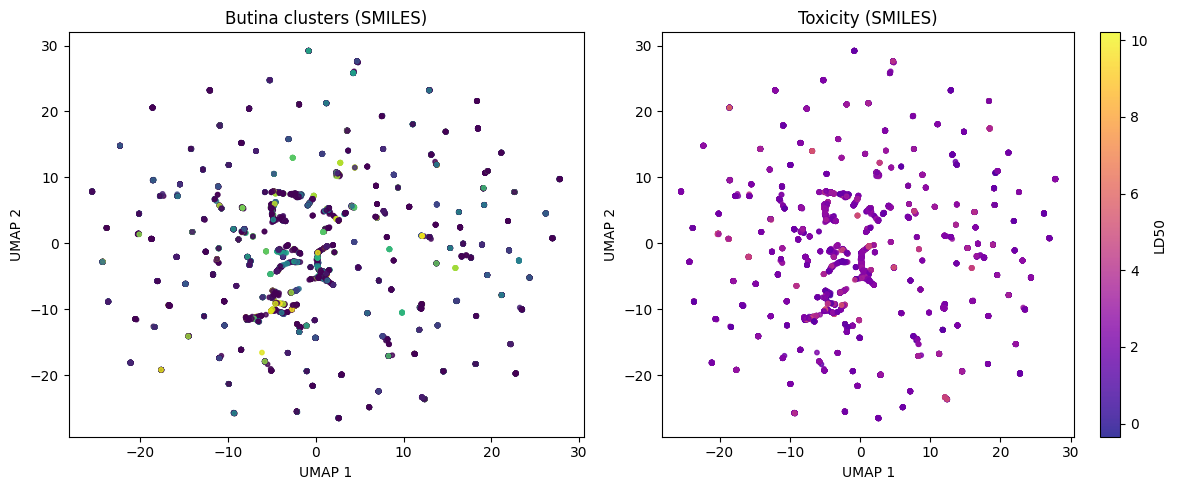

In [53]:
plot_umap(smiles_embed, smiles_labels, tox["ld_50"], "SMILES")

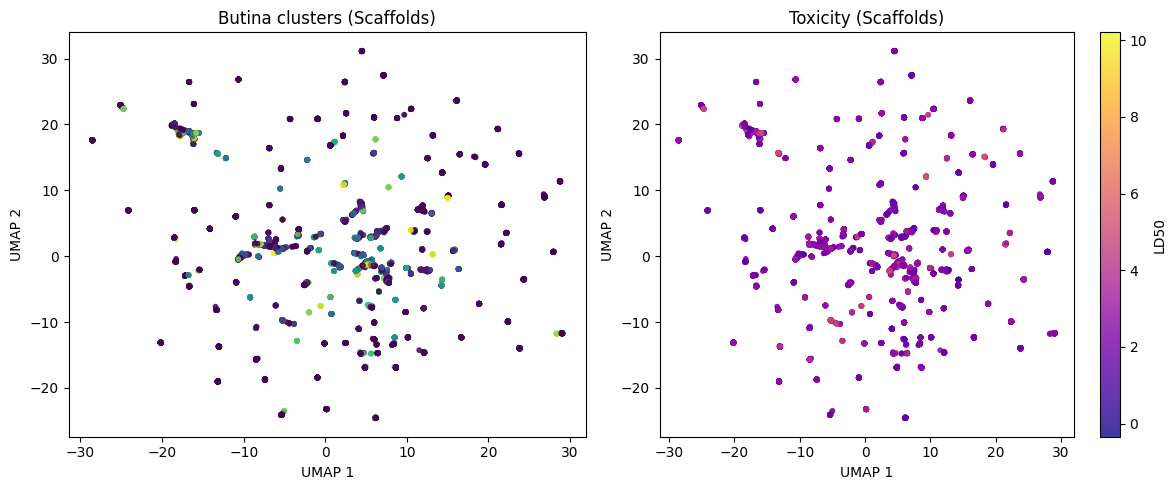

In [54]:
plot_umap(scaf_embed, scaf_labels, tox["ld_50"], "Scaffolds")

#### 9) Discussion points
1) How did the scaffolds and functional groups perform in the model performance in comparison the molecular descriptors? Comment on possible reasons. Which combination was suited best?
2) Is the One-Hot Encoding needed in this case?
3) Did the feature filtering (variance, correlation) have an improving effect? Explain!
4) Consider to make this kind of workflow for feature comparison more generally usable: How would a clean solution look? How could you ensure compatibility with other models? How would the function / pipeline look schematically?
5) Visualisation: Using the scaffold fingerprints and the fingerprints for the entire molecule makes a huge difference. What is reason for this effect? Discuss this approach in contrast to similarity thresholds in the Butina clustering.
6) When might scaffolding prove useful?
7) Is toxicity correlated to molecular structure? I.e. what did the toxicity map in UMAP space reveal?


1. The molecular descriptors one `X_md`performed the best. The combination of all performed the second best. This lets us assume that detecting toxicity is a very complex task and depends on many different molecular properties and only functional groups alone may not be able to detect everything.
2. One-Hot-Encoding is required because most regression models are unable to operate on categorical data and require numerical input which is achieved by the encoding.
3. Feature filtering made the performance slightly worse. This means that some correlated or low-variance features were still important information for the model.
4. A reusable workflow could be implemented using python classes and functions as well as using the built-in sklearn pipeline where a model can be trained more easily.
5. Scaffolds represent only key structures of the molecules whereas the fingerprint contains everything. This means that the clusters in the scaffolding become less noisy and clusters are more distinct. In the fingerprint one, it is very noisy and clusters appear more scattered.
6. Scaffolds are important to identify chemical families or shared core structures. This can be very helpful when prior theoretical or practical information is available and it is already known that a certain structure might be a binding site for a molecule so similar ones can be searched for more effectively rather than looking at the whole fingerpint.
7. The toxicity map in UMAP space did not show strong clustering of highly toxic compounds. This suggests that toxicity is only weakly correlated with the overall molecular structure represented in the fingerprints. It probably depends on more complex interactions that are not captured by simple molecular structure.